In [2]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random

from models import device, ImageSet, ClassicUNet, AttentionUNet, ResNetUNet, ResNetAttendedUNet, SegFormerWrapper

c:\Users\niktu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
torch.manual_seed(67)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

In [4]:
def iou_score(pred, target, thr):
    pred = (pred > thr).float()
    target = (target > thr).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = ((pred + target) > 0).float().sum(dim=(1,2,3))
    return ((intersection + 1e-8) / (union + 1e-8)).mean().item()

def dice_score(pred, target, thr):
    pred = (pred > thr).float()
    target = (target > thr).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    denom = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*intersection + 1e-8) / (denom + 1e-8)).mean().item()

In [5]:
def test(model, test_dataloader, thr, apply_sigmoid=True):
    model.eval()
    total_iou = 0
    total_dice = 0
    n = 0
    with torch.no_grad():
        for sat, mask in test_dataloader:
            sat = sat.to(device)
            mask = mask.to(device)
            pred = model.forward(sat)
            if apply_sigmoid:
                pred = torch.sigmoid(pred)
            total_iou += iou_score(pred, mask, thr)
            total_dice += dice_score(pred, mask, thr)
            n += 1
    print("avg_iou =", round(total_iou/n, 4))
    print("avg_dice =", round(total_dice/n, 4))
    return total_iou/n, total_dice/n

In [6]:
batch_size = 8

test_loader = DataLoader(ImageSet('test'), batch_size=batch_size, shuffle=False, num_workers=0,
                          worker_init_fn=seed_worker, pin_memory=True, persistent_workers=False)

In [19]:
# Select model here: "classicunet", "resnetunet", "attendedunet", "resnetattendedunet", "segformer", "scratchsegformer"
selected_model = "resnetunet"
manual = "resnetunetFOCAL-BCE-DICELoss_model"

if selected_model == "classicunet":
    model = ClassicUNet(num_classes=2)
    model_name = "classicunet_model"
elif selected_model == "resnetunet":
    model = ResNetUNet(num_classes=2)
    model_name = "resnetunet_model"
elif selected_model == "attendedunet":
    model = AttentionUNet(num_classes=2)
    model_name = "attendedunet_model"
elif selected_model == "resnetattendedunet":
    model = ResNetAttendedUNet(num_classes=2)
    model_name = "resnetattendedunet_model"
elif selected_model == "segformer":
    model = SegFormerWrapper() 
    model_name = "segformer_model"
elif selected_model == "scratchsegformer":
    model = SegFormerWrapper(pretrained=False) 
    model_name = "scratchsegformer_model"

model.to(device)
model.load_state_dict(torch.load(f'.\\Saved Models\\{model_name if not manual else manual}.pth'))

<All keys matched successfully>

In [20]:
print("Testing...")
test(model, test_loader, 0.25)
print("Testing complete!")

Testing...
avg_iou = 0.3613
avg_dice = 0.5208
Testing complete!


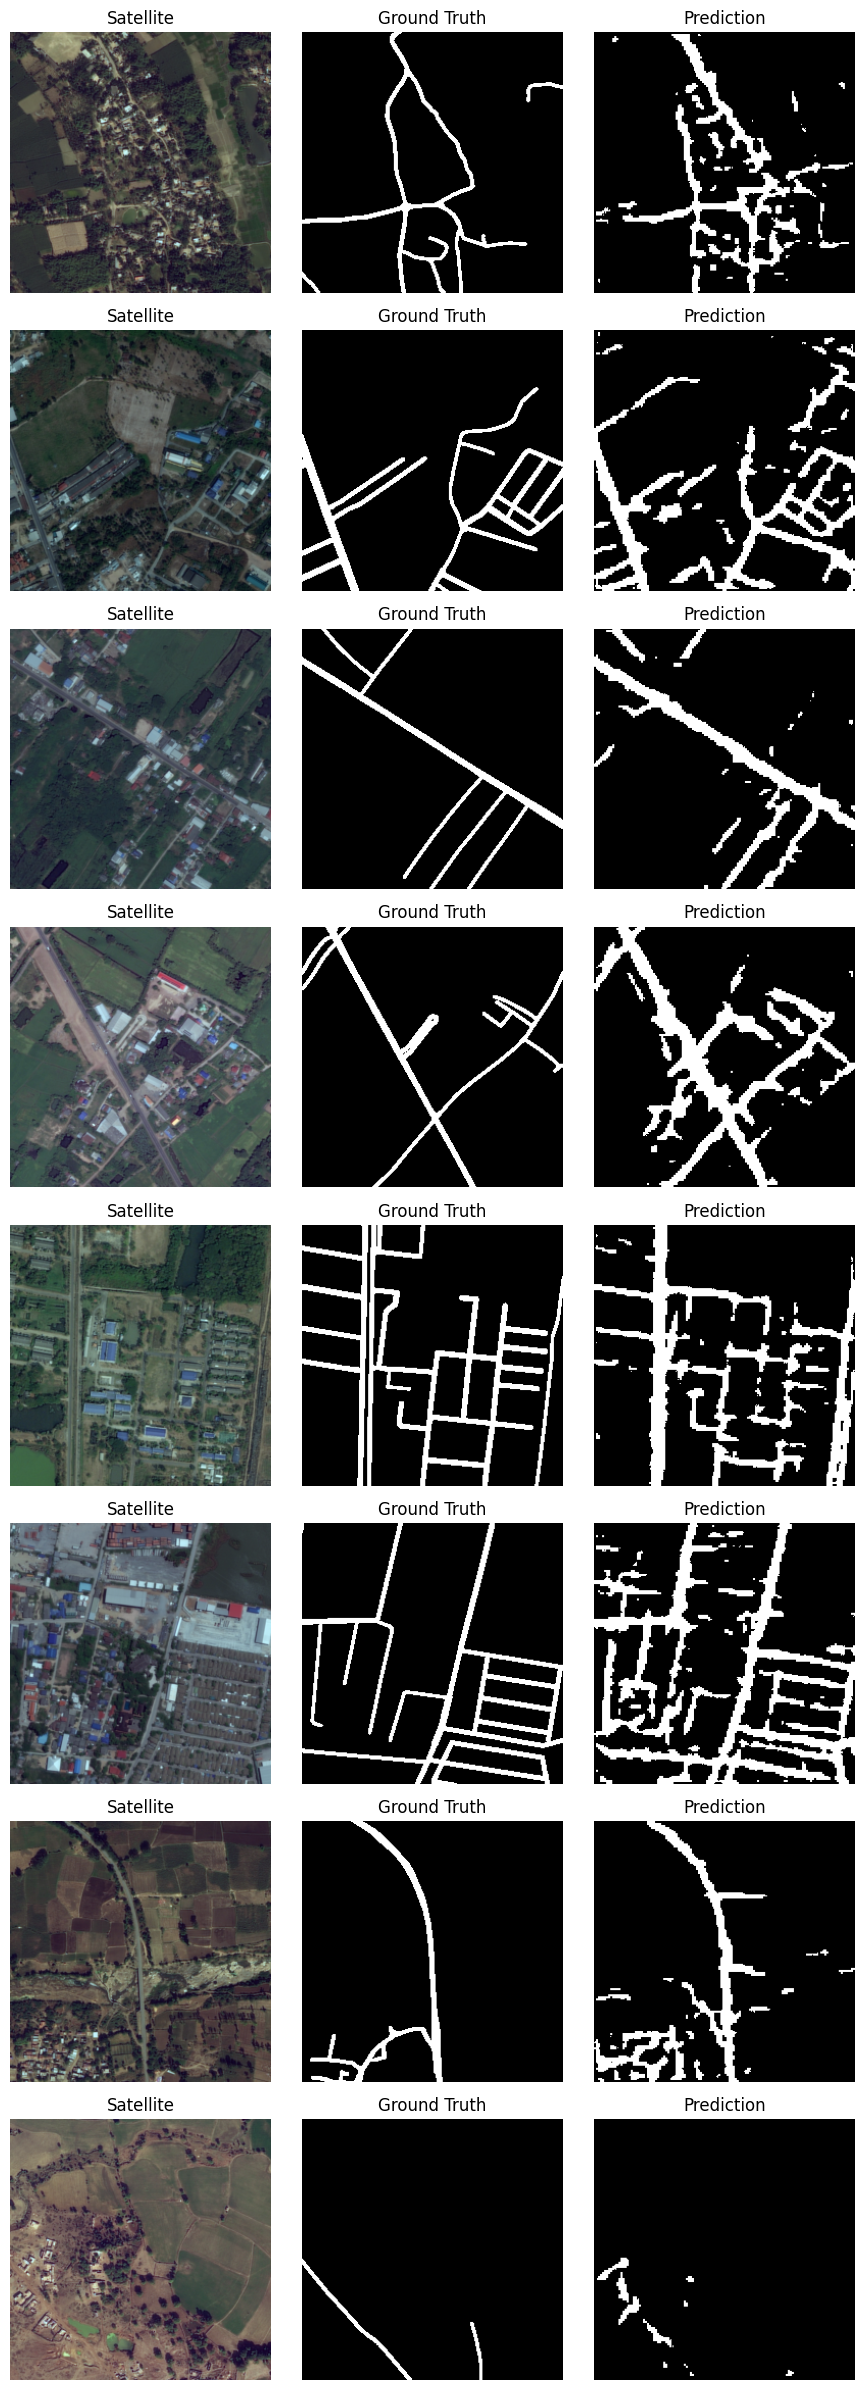

In [21]:
model.eval()
sat, mask = next(iter(test_loader))
sat = sat.to(device)
mask = mask.to(device)

with torch.no_grad():
    pred = torch.sigmoid(model.forward(sat))

n_show = min(8, sat.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))
for i in range(n_show):
    img = sat[i].cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-7)
    gt = mask[i,0].cpu().numpy()
    pr = (pred[i,0].cpu().numpy()>0.25).astype(float)
    # print(pr)
    axes[i,0].imshow(img)
    axes[i,0].set_title("Satellite")
    axes[i,1].imshow(gt, cmap='gray', vmin=0, vmax=1)
    axes[i,1].set_title("Ground Truth")
    axes[i,2].imshow(pr, cmap='gray', vmin=0, vmax=1)
    axes[i,2].set_title("Prediction")
    for ax in axes[i]:
        ax.axis('off')
plt.tight_layout()
plt.savefig(f'.\\Graphs and Images\\{model_name if not manual else manual}_predictions.png')
plt.show()